In [1]:
import pandas as pd
import numpy as np

In [2]:
df= pd.read_csv("Salary Data.csv")
print("Dataset size :", df.shape)
df.sample(5)


Dataset size : (375, 6)


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
355,40.0,Male,Bachelor's,Senior Financial Analyst,12.0,130000.0
210,38.0,Male,Master's,Senior IT Consultant,9.0,110000.0
285,44.0,Female,PhD,Senior Product Designer,15.0,150000.0
131,29.0,Male,Bachelor's,Junior Web Designer,3.0,45000.0
174,26.0,Female,Master's,Junior Data Scientist,1.5,45000.0


# Data Cleaning

In [3]:
df.isnull().sum() #missing values

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [4]:
df.duplicated().sum() # duplicate values

50

In [5]:
duplicates = df[df.duplicated(keep=False)]
duplicates = duplicates.sort_values(by=list(df.columns))

duplicates

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
140,28.0,Male,Bachelor's,Junior Business Analyst,2.0,40000.0
195,28.0,Male,Bachelor's,Junior Business Analyst,2.0,40000.0
212,28.0,Male,Bachelor's,Junior Business Development Associate,2.0,40000.0
253,28.0,Male,Bachelor's,Junior Business Development Associate,2.0,40000.0
283,29.0,Female,Bachelor's,Junior Business Development Associate,1.5,35000.0
...,...,...,...,...,...,...
306,49.0,Female,Master's,Director of Marketing,21.0,180000.0
217,50.0,Female,PhD,Director of Operations,22.0,180000.0
258,50.0,Female,PhD,Director of Operations,22.0,180000.0
172,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# removing duplicates and missing values
df = df.drop_duplicates()
df = df.dropna()

In [7]:
df.shape

(324, 6)

# EDA

In [8]:
import matplotlib.pyplot as plt

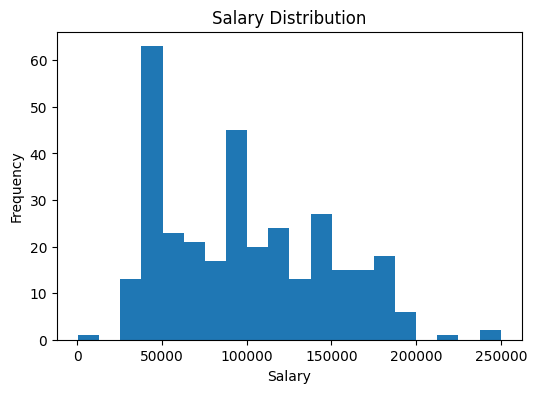

In [9]:
plt.figure(figsize=(6,4))
plt.hist(df['Salary'], bins=20)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

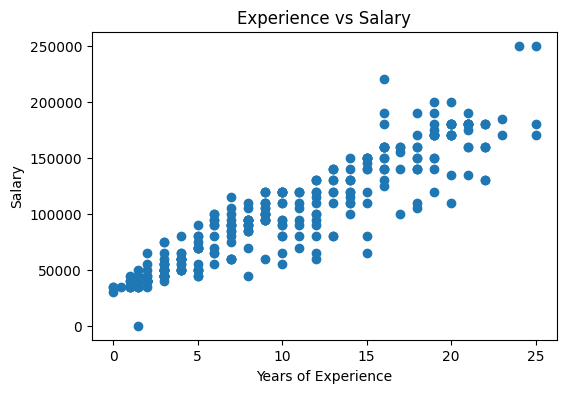

In [10]:
plt.figure(figsize=(6,4))
plt.scatter(df['Years of Experience'], df['Salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.show()

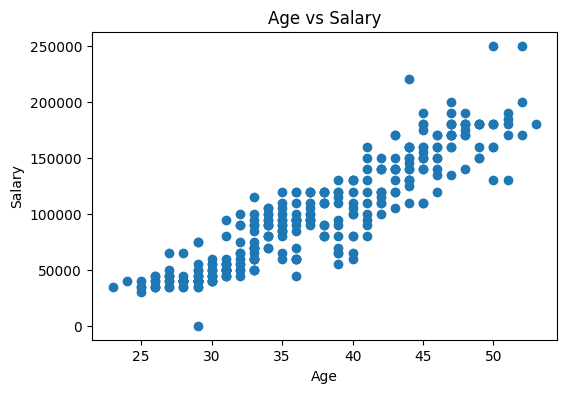

In [11]:
plt.figure(figsize=(6,4))
plt.scatter(df['Age'], df['Salary'])
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Age vs Salary')
plt.show()

# Preprocessing

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [13]:
categorical_cols = ["Gender", "Education Level", "Job Title"]
numeric_cols = ["Age", "Years of Experience"]

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

In [15]:
# Features
X = df.drop("Salary", axis=1)

# Target
y = df["Salary"]

# Train Test Split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Model Building

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Education Level',
                                                   'Job Title']),
                                                 ('num', 'passthrough',
                                                  ['Age',
                                                   'Years of Experience'])])),
                ('regressor', LinearRegression())])

In [18]:
pred = model.predict(X_test)

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_error

print("MAE:", mean_absolute_error(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2 Score:", r2_score(y_test, pred))


MAE: 12304.96358122753
MSE: 251280981.83699614
RMSE: 15851.844745549211
R2 Score: 0.8670321130384679


# Model Prediction

In [20]:
new_employee = pd.DataFrame({
    'Age':[21],
    'Gender':['Male'],
    'Education Level':['Bachelor\'s'],
    'Job Title':['Software Engineer'],
    'Years of Experience':[0]
})

predicted_salary = model.predict(new_employee)
print("Predicted Salary: {:.2f} Dollar per year".format(predicted_salary[0]))

Predicted Salary: 59731.84 Dollar per year
